Работу выполнил: Резников Иван, Р3122

---

# 1. Первичный анализ данных

Подгрузим библиотеки, которые точно понадобятся:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

А теперь данные:

In [2]:
url_train = 'https://raw.githubusercontent.com/rebeccabilbro/titanic/refs/heads/master/data/train.csv'
url_test = 'https://raw.githubusercontent.com/rebeccabilbro/titanic/refs/heads/master/data/test.csv'

df = pd.read_csv(url_train)

Проверим подгрузились ли данные:

In [3]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


Посмотрим какого типа данные в датасете:

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Текстовый формат имеют поля: Name,Sex, SibSp, Parch, Ticket, Cabin, Embarked

---

Посчитаем сколько значений Null в каждом из столбцов:

In [5]:
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Получим числовую характеристику числовых признаков:

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


Построим гистограммы распределения для числовых признаков:

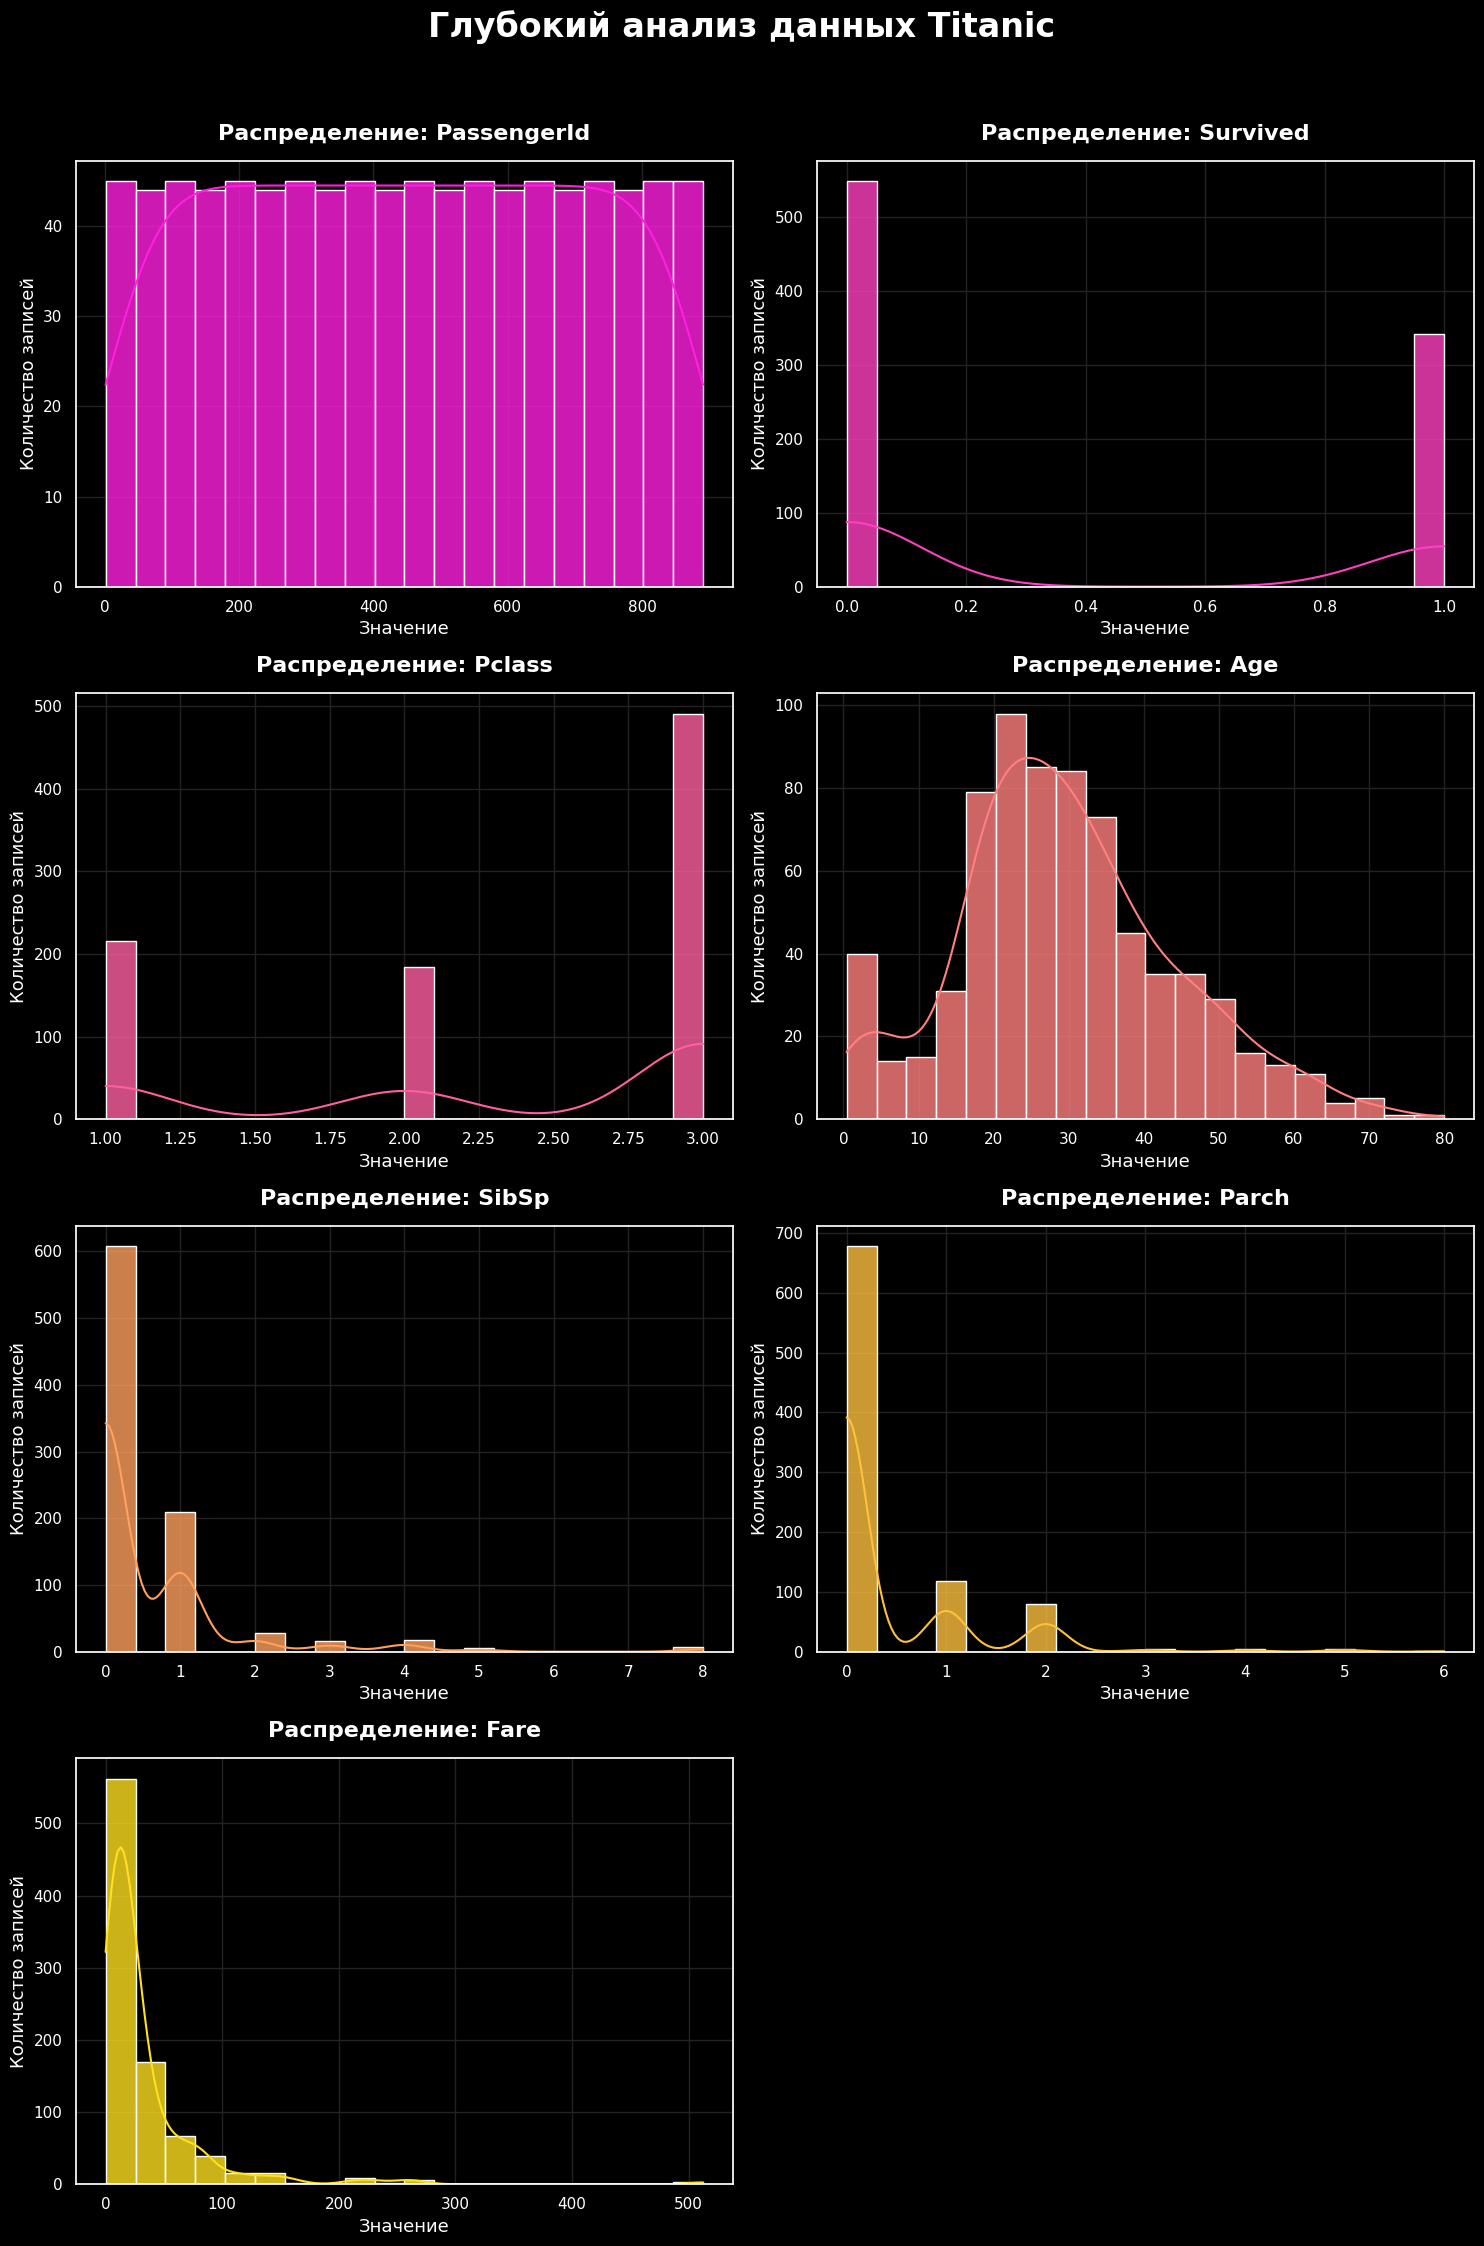

In [7]:
plt.style.use('dark_background')

sns.set_theme(style="darkgrid", rc={
    "axes.facecolor": "#000000",   # Черный фон самих графиков
    "figure.facecolor": "#000000", # Черный фон всей картинки
    "grid.color": "#222222",       # Цвет сетки
})

numeric_cols = df.select_dtypes(include=['number']).columns

fig, axes = plt.subplots(nrows=(len(numeric_cols) + 1) // 2, ncols=2, figsize=(15, 22))
axes = axes.flatten()

colors = sns.color_palette("spring", len(numeric_cols))

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color=colors[i], bins=20, alpha=0.8, edgecolor='white')

    axes[i].set_title(f'Распределение: {col}', fontsize=16, fontweight='bold', color='white', pad=15)
    axes[i].set_xlabel('Значение', fontsize=13, color='white')
    axes[i].set_ylabel('Количество записей', fontsize=13, color='white')
    axes[i].tick_params(axis='both', colors='white', labelsize=11)

# Удаляем пустой график
fig.delaxes(axes[7])

plt.suptitle('Глубокий анализ данных Titanic', fontsize=24, y=1.02, fontweight='bold', color='white')

plt.tight_layout()
plt.show()

Получились красивые графики распределения

---

# 2. Обработка пропусков

Определим столбцы с пропусками:

In [8]:
null_cols = df.isna().sum()
null_cols = null_cols[null_cols > 0]

null_cols

,0
Age,177
Cabin,687
Embarked,2


## Отдельно обработаем каждый из столбцов:

### Столбец Age:

Посчитаем средний и медианный возраст пассажиров:

In [9]:
age_mean = df['Age'].mean()
age_median = df['Age'].median()

print(f'Средний возраст: {round(age_mean, 2)}\nМедианный возраст: {round(age_median)}')

Средний возраст: 29.7
Медианный возраст: 28


Заполним пропуски медианным значением:

In [10]:
df['Age'] = df['Age'].fillna(age_median)

print(f'Количество пропусков в Age: {df['Age'].isna().sum()}')

Количество пропусков в Age: 0


Создадим новый категориальный признак на основе Age:

In [11]:
age_bins = [0, 12, 18, 60, 100]

age_labels = ['Child', 'Teenager', 'Adult', 'Senior']

df['Age_group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

print(df['Age_group'].value_counts())
display(df[['Age', 'Age_group']].head(10))

Age_group
Adult       730
Teenager     70
Child        69
Senior       22
Name: count, dtype: int64


,Age,Age_group
0,22.0,Adult
1,38.0,Adult
2,26.0,Adult
3,35.0,Adult
4,35.0,Adult
5,28.0,Adult
6,54.0,Adult
7,2.0,Child
8,27.0,Adult
9,14.0,Teenager


### Столбец Embarked

Найдем моду:

In [12]:
embarked_mode = df['Embarked'].mode()[0]

Заполним пропуски модой:

In [13]:
df['Embarked'] = df['Embarked'].fillna(embarked_mode)


print(f'Количество пропусков в Embarked: {df['Embarked'].isna().sum()}')

Количество пропусков в Embarked: 0


### Столбец Cabin

In [14]:
df['Cabin'].isna().sum()

np.int64(687)

Очень много пропусков, но удалять не стоит, надо достать максимально возможную информацию. Будем сохранять первую букву - палубу, а для всех нулл значений - U (Unknown)

In [15]:
df['Cabin_letter'] = [str(x)[0] if pd.notnull(x) else 'U' for x in df['Cabin']]

df[['Cabin', 'Cabin_letter']].head(5)

,Cabin,Cabin_letter
0,NaN,U
1,C85,C
2,NaN,U
3,C123,C
4,NaN,U


# 3. Работа с типами данных

Преобразуем Pclass в категориальный тип данных (из числового)
[1 - F, 2 - S, 3 - T]:

In [16]:
pclass_new = {1: 'F', 2: 'S', 3: 'T'}

df['Pclass'] = df['Pclass'].map(pclass_new)

df['Pclass'].head()

,Pclass
0,T
1,F
2,T
3,F
4,T


Cоздадим новый признак Title из столбца Name

In [17]:
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

title_counts = df['Title'].value_counts()
rare_titles = title_counts[title_counts < 15].index

df['Title'] = df['Title'].replace(rare_titles, 'Rare')

df['Title'].value_counts()

,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Rare,27


Преобразуем Sex в числовой формат:

In [18]:
new_sex = {'male': 1, 'female': 0}
df['Sex'] = df['Sex'].map(new_sex)

df['Sex'].value_counts()

,count
Sex,
1,577
0,314


Создадим новый признак - FamilySize:

In [19]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

df[['FamilySize', 'Name']].head()

,FamilySize,Name
0,2,"Braund, Mr. Owen Harris"
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
2,1,"Heikkinen, Miss. Laina"
3,2,"Futrelle, Mrs. Jacques Heath (Lily May Peel)"
4,1,"Allen, Mr. William Henry"


Создадим еще 1 признак - IsAlone:

In [20]:
df['IsAlone'] = [1 if x == 1 else 0 for x in df['FamilySize']]


df[['Name', 'FamilySize', 'IsAlone']]

,Name,FamilySize,IsAlone
0,"Braund, Mr. Owen Harris",2,0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",2,0
2,"Heikkinen, Miss. Laina",1,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",2,0
4,"Allen, Mr. William Henry",1,1
...,...,...,...
886,"Montvila, Rev. Juozas",1,1
887,"Graham, Miss. Margaret Edith",1,1
888,"Johnston, Miss. Catherine Helen ""Carrie""",4,0
889,"Behr, Mr. Karl Howell",1,1


# 4. Удаление выбросов

Построим ящик с усами для Fare:

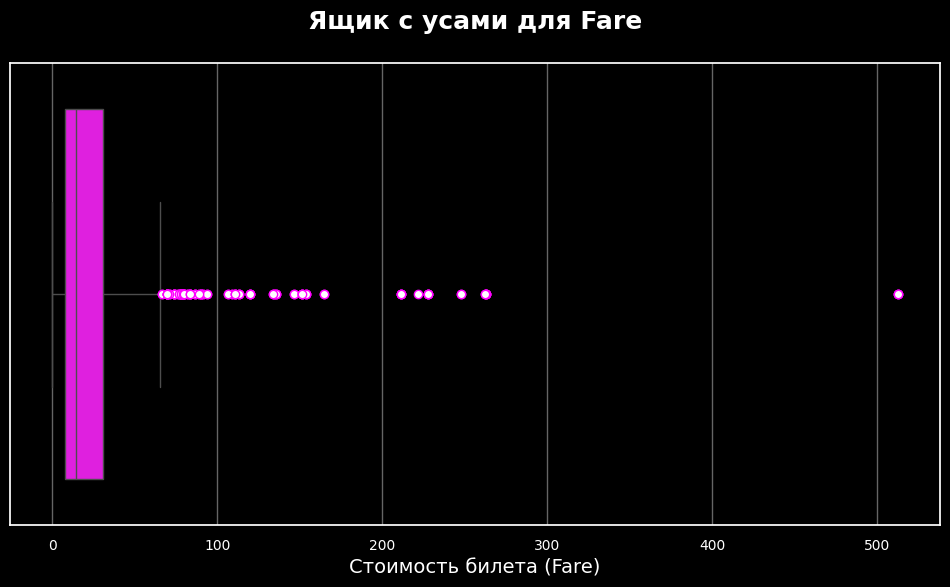

In [21]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(x=df['Fare'], color='#ff00ff',
            flierprops={'markerfacecolor': 'white', 'markeredgecolor': '#ff00ff'})
plt.title('Ящик с усами для Fare', fontsize=18, fontweight='bold', color='white', pad=25)
plt.xlabel('Стоимость билета (Fare)', fontsize=14, color='white')
ax.tick_params(axis='x', colors='white', labelsize=10)

plt.grid(axis='x', alpha=0.4, color='white')

plt.show()

Определим выбросы с помощью IQR-метода

In [22]:
q1 = df['Fare'].quantile(0.25)
q3 = df['Fare'].quantile(0.75)

IQR = q3 - q1
lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR

print(f'Диапазон: ({lower_bound}; {upper_bound})')

out = df[(df['Fare'] < lower_bound) | (df['Fare'] > upper_bound)]

print(f'Количество выбросов: {len(out)}\nПроцент выбросов: {len(out) / len(df) * 100:.2f}%')

Диапазон: (-26.724; 65.6344)
Количество выбросов: 116
Процент выбросов: 13.02%


Построим график распределения по Age:

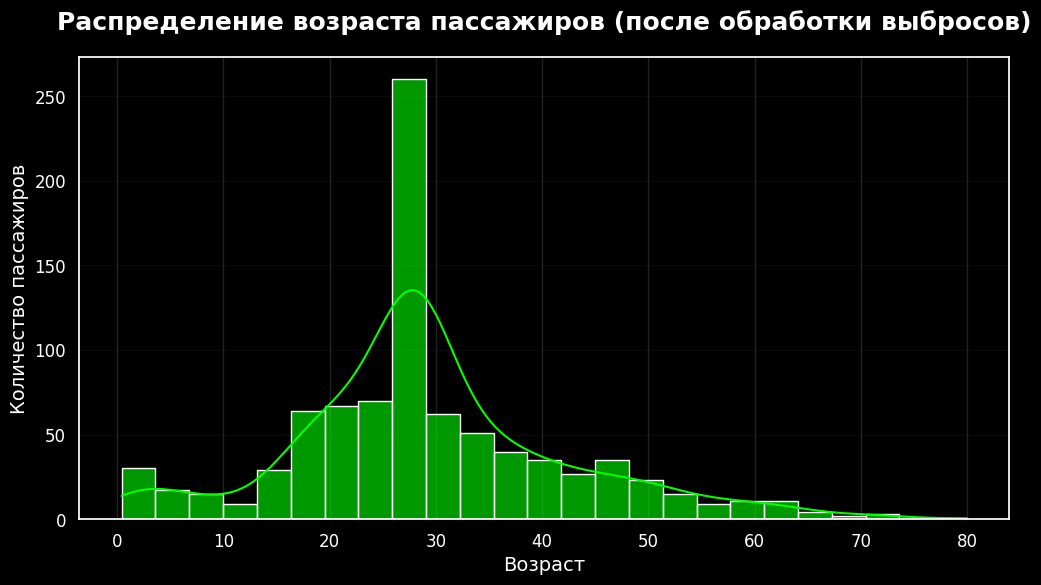

In [23]:
plt.figure(figsize=(12, 6))

sns.histplot(df['Age'], kde=True, color='lime', bins=25, alpha=0.6, edgecolor='white')

plt.title('Распределение возраста пассажиров (после обработки выбросов)',
          fontsize=18, fontweight='bold', color='white', pad=20)
plt.xlabel('Возраст', fontsize=14, color='white')
plt.ylabel('Количество пассажиров', fontsize=14, color='white')

plt.tick_params(axis='both', colors='white', labelsize=12)
plt.grid(axis='y', alpha=0.3)

plt.show()

Применим винзоризацию для Fare (отбросим хвосты 🦎):

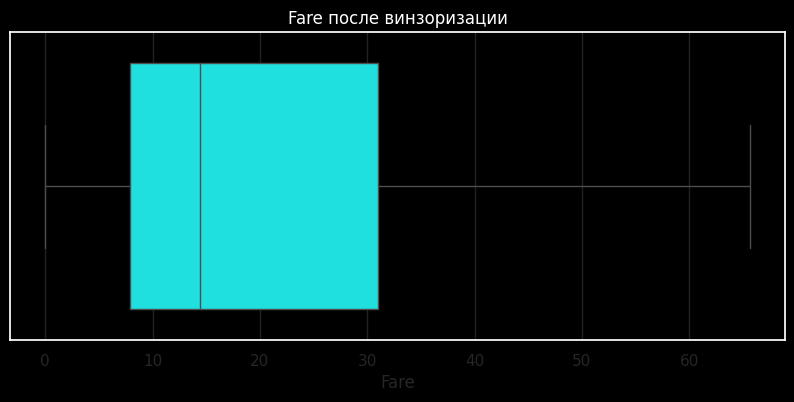

In [24]:
df.loc[df['Fare'] > upper_bound, 'Fare'] = upper_bound

plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Fare'], color='cyan')
plt.title('Fare после винзоризации', color='white')
plt.show()

Заменим экстремальные значения Age на 95 перцентиль:

In [25]:
age_95 = df['Age'].quantile(0.95)

df.loc[df['Age'] > age_95, 'Age'] = age_95

print(f"Максимальный возраст в датасете теперь: {df['Age'].max():.1f} как и {age_95}")

Максимальный возраст в датасете теперь: 54.0 как и 54.0


# 5. Агрегация данных

Посчитаем среднее выживание по классам:

In [26]:
df.groupby('Pclass')['Survived'].mean()

,Survived
Pclass,
F,0.629630
S,0.472826
T,0.242363


Сгруппируем данные по классу и полу:

In [27]:
df.groupby(['Pclass', 'Sex'])['Survived'].mean()

Pclass  Sex
F       0      0.968085
        1      0.368852
S       0      0.921053
        1      0.157407
T       0      0.500000
        1      0.135447
Name: Survived, dtype: float64

Посчитаем медианный возраст по портам посадки

In [28]:
median_age_embarked = df.groupby('Embarked')['Age'].median()

median_age_embarked

,Age
Embarked,
C,28.0
Q,28.0
S,28.0


Создадим сводную таблицу выживаемости по новым признакам:

In [29]:
pivot_new_features = df.pivot_table(
    index='Title',
    columns='IsAlone',
    values='Survived',
    aggfunc='mean'
)

print("Выживаемость по титулам и признаку одиночества (1 - одинок, 0 - с семьей):")
pivot_new_features

Выживаемость по титулам и признаку одиночества (1 - одинок, 0 - с семьей):


IsAlone,0,1
Title,,
Master,0.575000,NaN
Miss,0.634146,0.750000
Mr,0.166667,0.153652
Mrs,0.771429,0.900000
Rare,0.428571,0.450000


Сохраним очищенные данные в новый CSV-файл:

In [30]:
df.to_csv('titanic_final.csv', index=False)

# 6. Вычислим метрики качества очистки данных

Проанализируем нашу очистку данных:

In [31]:
missing_data = df.isnull().sum()
total_rows = len(df)

completion_percentage = ((total_rows - missing_data) / total_rows) * 100

print("Процент заполненности признаков:")
print(completion_percentage.round(2).astype(str) + '%')

Процент заполненности признаков:
PassengerId     100.0%
Survived        100.0%
Pclass          100.0%
Name            100.0%
Sex             100.0%
Age             100.0%
SibSp           100.0%
Parch           100.0%
Ticket          100.0%
Fare            100.0%
Cabin            22.9%
Embarked        100.0%
Age_group       100.0%
Cabin_letter    100.0%
Title           100.0%
FamilySize      100.0%
IsAlone         100.0%
dtype: object


Проверим количество уникальных значений в категориальных признаках:

In [32]:
categ_cols = df.select_dtypes(include=['object']).columns.tolist()


unique = df[categ_cols].nunique()

print(f'Количество уникальных значений: \n{unique}')


Количество уникальных значений: 
Pclass            3
Name            891
Ticket          681
Cabin           147
Embarked          3
Cabin_letter      9
Title             5
dtype: int64


Распределение значений после трансформации:

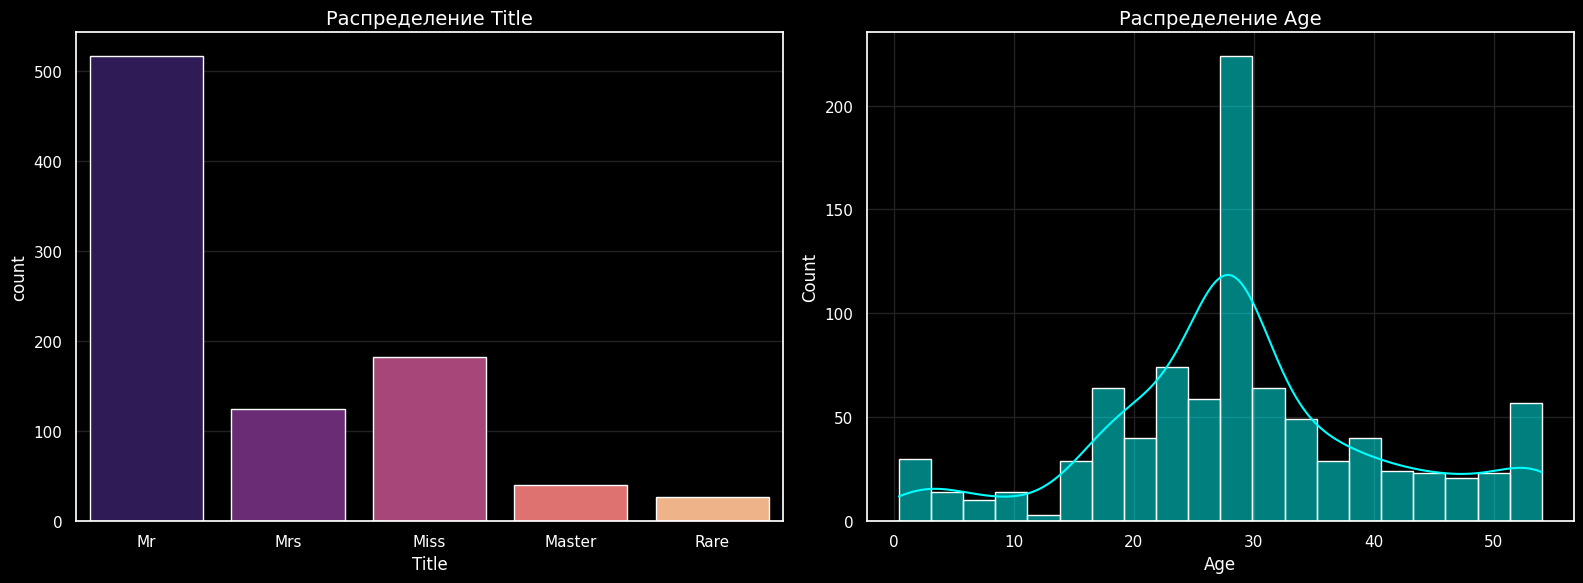

In [33]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=df, x='Title', ax=ax[0], palette='magma', hue='Title')
ax[0].set_title('Распределение Title', color='white', fontsize=14)

sns.histplot(df['Age'], kde=True, color='cyan', ax=ax[1], bins=20)
ax[1].set_title('Распределение Age', color='white', fontsize=14)

for a in ax:
    a.tick_params(colors='white')
    a.xaxis.label.set_color('white')
    a.yaxis.label.set_color('white')

plt.tight_layout()
plt.show()

Посмотрим на корреляцию между новыми признаками:

In [37]:
from scipy.stats import chi2_contingency

def get_cramers_v(var1, var2):
    """Вычисляет коэффициент V Крамера между двумя признаками."""
    crosstab = pd.crosstab(var1, var2)
    chi2 = chi2_contingency(crosstab)[0]
    n = crosstab.sum().sum()
    phi2 = chi2 / n
    r, k = crosstab.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

cols_to_check = ['Survived', 'Pclass', 'Sex', 'Title', 'IsAlone', 'Embarked']

corr_matrix = pd.DataFrame(index=cols_to_check, columns=cols_to_check)

for col1 in cols_to_check:
    for col2 in cols_to_check:
        corr_matrix.loc[col1, col2] = get_cramers_v(df[col1], df[col2])

corr_matrix = corr_matrix.astype(float)

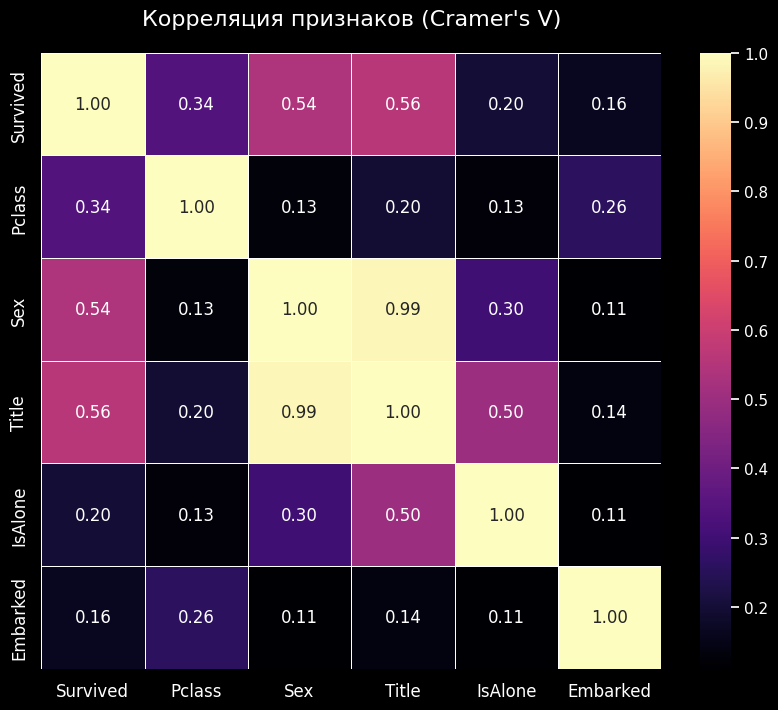

In [40]:
plt.figure(figsize=(10, 8))
plt.style.use('dark_background')

sns.heatmap(corr_matrix, annot=True, cmap='magma', fmt='.2f', linewidths=0.5)

plt.title("Корреляция признаков (Cramer's V)", color='white', fontsize=16, pad=20)
plt.xticks(color='white', fontsize=12)
plt.yticks(color='white', fontsize=12)

plt.show()

**Итог:** провел полную очистку и подготовку данных. Сначала устранил пропуски: возраст заполнил медианой, порт посадки - модой, обработал выбросы для стоимости билетов по методу IQR и ограничил экстремальный возраст. Также я добавил новые признаки: извлек титулы из имен, что позволило выделить социальный статус пассажиров, создал признак размера семьи (в тч одиночек).

Через коэффициент V Крамера подтвердил, что выживаемость сильнее всего связана с полом и титулом, также класс каюты тоже имеет достаточно сильную связь. В итоге получился чистый датасет, готовый к обучению